### В этом ноутбуке основной анализ данных (воспроизведение таблиц из статьи)

(Подготовку данных можно посмотреть в другом ноутбуке указаном в README)


Сначала импорты

In [91]:
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install statsmodels
%pip install scipy
%pip install pyarrow
%pip install fastparquet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [92]:
import pandas as pd
import os
PARQUET_FILES_DIR = "data_for_analysis"

us_full_time = pd.read_parquet(os.path.join(PARQUET_FILES_DIR, "us_processed_full_time.parquet"), engine="fastparquet")
us_sub1 = pd.read_parquet(os.path.join(PARQUET_FILES_DIR, "us_processed_sub1.parquet"), engine="fastparquet")
us_sub2 = pd.read_parquet(os.path.join(PARQUET_FILES_DIR, "us_processed_sub2.parquet"), engine="fastparquet")

uk_full_time = pd.read_parquet(os.path.join(PARQUET_FILES_DIR, "uk_processed_full_time.parquet"), engine="fastparquet")
uk_sub1 = pd.read_parquet(os.path.join(PARQUET_FILES_DIR, "uk_processed_sub1.parquet"), engine="fastparquet")
uk_sub2 = pd.read_parquet(os.path.join(PARQUET_FILES_DIR, "uk_processed_sub2.parquet"), engine="fastparquet")

bd_full_time = pd.read_parquet(os.path.join(PARQUET_FILES_DIR, "bd_processed_full_time.parquet"), engine="fastparquet")
bd_sub1 = pd.read_parquet(os.path.join(PARQUET_FILES_DIR, "bd_processed_sub1.parquet"), engine="fastparquet")
bd_sub2 = pd.read_parquet(os.path.join(PARQUET_FILES_DIR, "bd_processed_sub2.parquet"), engine="fastparquet")


Теперь фунция для подсчета статистик и параметров из первой таблицы статьи (table 1)

In [93]:
from scipy.stats import skew, kurtosis, jarque_bera
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox

def calculate_table1_stats(series):
    s = series.dropna()
    
    stats = {
        "Mean": s.mean(),
        "Median": s.median(),
        "Std. Dev.": s.std(),
        "Skewness": skew(s),
        "Kurtosis": kurtosis(s, fisher=False) 
    }

    jb_stat, jb_pvalue = jarque_bera(s)
    stats["JB"] = jb_stat

    lb_test = acorr_ljungbox(s, lags=[1, 5], return_df=True)
    stats["LB(1)"] = lb_test['lb_stat'].iloc[0]
    stats["LB(5)"] = lb_test['lb_stat'].iloc[1]

    adf_result = adfuller(s, maxlag=10, autolag=None, result_object=False)
    stats["ADF(10)"] = adf_result[0]

    return pd.Series(stats)


Таблица 1 для США

In [94]:
TIME_PERIODS = {
    "full_time":["1992-01-03", "2000-04-20"],
    "sub1":["1992-01-03", "1997-05-30"],
    "sub2":["1997-06-02", "2000-04-20"]
    }

table_1_panel_a_us = pd.DataFrame({
    "ERUS": calculate_table1_stats(us_full_time["ER_US"]),
    "YUS": calculate_table1_stats(us_full_time["Y_US"]),
    "DLDJIA": calculate_table1_stats(us_full_time["s_US"]),
})
table_1_panel_b_us = pd.DataFrame({
    "ERUS": calculate_table1_stats(us_sub1["ER_US"]),
    "YUS": calculate_table1_stats(us_sub1["Y_US"]),
    "DLDJIA": calculate_table1_stats(us_sub1["s_US"]),
})
table_1_panel_c_us = pd.DataFrame({
    "ERUS": calculate_table1_stats(us_sub2["ER_US"]),
    "YUS": calculate_table1_stats(us_sub2["Y_US"]),
    "DLDJIA": calculate_table1_stats(us_sub2["s_US"]),
})

print(f"panel a:{TIME_PERIODS["full_time"]}\n")
print(table_1_panel_a_us.round(4))
print("--------------")
print(f"panel b:{TIME_PERIODS["sub1"]}\n")
print(table_1_panel_b_us.round(4))
print("--------------")
print(f"panel c:{TIME_PERIODS["sub2"]}\n")
print(table_1_panel_c_us.round(4))

panel a:['1992-01-03', '2000-04-20']

                ERUS       YUS     DLDJIA
Mean          0.0420    0.0029     0.0592
Median        0.0480    0.0000     0.0659
Std. Dev.     0.9181    0.4435     0.9181
Skewness     -0.5329   -0.4307    -0.5355
Kurtosis      9.1614    5.6174     9.1667
JB         3383.6633  657.0940  3390.2493
LB(1)         0.4997    8.2107     0.4930
LB(5)         8.8029   23.5971     8.8425
ADF(10)     -13.9927  -13.8173   -14.0028
--------------
panel b:['1992-01-03', '1997-05-30']

               ERUS       YUS    DLDJIA
Mean         0.0438    0.0006    0.0619
Median       0.0494    0.0000    0.0670
Std. Dev.    0.6847    0.4526    0.6846
Skewness    -0.2629   -0.5583   -0.2624
Kurtosis     4.5521    6.3029    4.5533
JB         151.3963  685.3084  151.5447
LB(1)        2.8544    3.9176    2.8351
LB(5)       13.7584   14.5592   13.7921
ADF(10)    -11.1977  -11.4282  -11.2078
--------------
panel c:['1997-06-02', '2000-04-20']

               ERUS      YUS    DLDJ

То же самое для Великобритании и Германии

In [95]:
table_1_panel_a_uk = pd.DataFrame({
    "ERUK": calculate_table1_stats(uk_full_time["ER_UK"]),
    "YUK": calculate_table1_stats(uk_full_time["Y_UK"]),
    "DLFTSE": calculate_table1_stats(uk_full_time["s_UK"]),
})
table_1_panel_b_uk = pd.DataFrame({
    "ERUK": calculate_table1_stats(uk_sub1["ER_UK"]),
    "YUK": calculate_table1_stats(uk_sub1["Y_UK"]),
    "DLFTSE": calculate_table1_stats(uk_sub1["s_UK"]),
})
table_1_panel_c_uk = pd.DataFrame({
    "ERUK": calculate_table1_stats(uk_sub2["ER_UK"]),
    "YUK": calculate_table1_stats(uk_sub2["Y_UK"]),
    "DLFTSE": calculate_table1_stats(uk_sub2["s_UK"]),
})

print(f"panel a:{TIME_PERIODS["full_time"]}\n")
print(table_1_panel_a_uk.round(4))
print("--------------")
print(f"panel b:{TIME_PERIODS["sub1"]}\n")
print(table_1_panel_b_uk.round(4))
print("--------------")
print(f"panel c:{TIME_PERIODS["sub2"]}\n")
print(table_1_panel_c_uk.round(4))

panel a:['1992-01-03', '2000-04-20']

               ERUK        YUK    DLFTSE
Mean         0.0241     0.0145    0.0437
Median       0.0295     0.0271    0.0484
Std. Dev.    0.9459     0.4794    0.9459
Skewness     0.0123    -0.1065    0.0068
Kurtosis     5.1148     6.8552    5.1190
JB         391.2158  1303.7991  392.7359
LB(1)       14.7495     0.3512   14.7334
LB(5)       27.8077     2.4863   27.8226
ADF(10)    -13.8993   -13.9417  -13.9041
--------------
panel b:['1992-01-03', '1997-05-30']

               ERUK       YUK    DLFTSE
Mean         0.0231    0.0116    0.0452
Median       0.0193    0.0301    0.0431
Std. Dev.    0.7441    0.5093    0.7440
Skewness     0.2449   -0.0173    0.2472
Kurtosis     6.5719    6.9952    6.5786
JB         740.3552  909.2017  743.3546
LB(1)        3.6575    0.1161    3.6372
LB(5)        4.5246    2.6352    4.4894
ADF(10)    -11.5843  -11.5826  -11.5928
--------------
panel c:['1997-06-02', '2000-04-20']

              ERUK       YUK   DLFTSE
Mean    

In [96]:
table_1_panel_a_bd = pd.DataFrame({
    "ERBD": calculate_table1_stats(bd_full_time["ER_BD"]),
    "YBD": calculate_table1_stats(bd_full_time["Y_BD"]),
    "DLDAX": calculate_table1_stats(bd_full_time["s_BD"]),
})
table_1_panel_b_bd = pd.DataFrame({
    "ERBD": calculate_table1_stats(bd_sub1["ER_BD"]),
    "YBD": calculate_table1_stats(bd_sub1["Y_BD"]),
    "DLDAX": calculate_table1_stats(bd_sub1["s_BD"]),
})
table_1_panel_c_bd = pd.DataFrame({
    "ERBD": calculate_table1_stats(bd_sub2["ER_BD"]),
    "YBD": calculate_table1_stats(bd_sub2["Y_BD"]),
    "DLDAX": calculate_table1_stats(bd_sub2["s_BD"]),
})

print(f"panel a:{TIME_PERIODS["full_time"]}\n")
print(table_1_panel_a_bd.round(4))
print("--------------")
print(f"panel b:{TIME_PERIODS["sub1"]}\n")
print(table_1_panel_b_bd.round(4))
print("--------------")
print(f"panel c:{TIME_PERIODS["sub2"]}\n")
print(table_1_panel_c_bd.round(4))

panel a:['1992-01-03', '2000-04-20']

               ERBD       YBD     DLDAX
Mean         0.0558    0.0087    0.0724
Median       0.0857    0.0221    0.1033
Std. Dev.    1.2286    0.3588    1.2285
Skewness    -0.3557   -0.4679   -0.3601
Kurtosis     6.1632    5.5953    6.1696
JB         905.3314  655.5414  909.9055
LB(1)        2.1382    0.1866    2.1226
LB(5)        8.4179    1.5810    8.4156
ADF(10)    -13.6635  -13.8849  -13.6754
--------------
panel b:['1992-01-03', '1997-05-30']

               ERBD       YBD     DLDAX
Mean         0.0411    0.0104    0.0595
Median       0.0673    0.0227    0.0881
Std. Dev.    0.9122    0.3578    0.9120
Skewness    -0.3014   -0.5268   -0.3020
Kurtosis     4.7465    6.0755    4.7500
JB         191.0160  591.3961  191.7861
LB(1)        0.0225    0.5038    0.0191
LB(5)        6.1356    5.4133    6.1116
ADF(10)    -11.4099  -11.3938  -11.4342
--------------
panel c:['1997-06-02', '2000-04-20']

              ERBD       YBD    DLDAX
Mean        0.0831

Дальше итоговая таблица 1 из статьи

In [97]:
table_1_panel_a_full = pd.concat([table_1_panel_a_us, table_1_panel_a_uk, table_1_panel_a_bd], axis=1)
print(f"TABLE 1\n{TIME_PERIODS["full_time"]}")
print(table_1_panel_a_full.round(4))
print("\n-------------------\n")
table_1_panel_b_full = pd.concat([table_1_panel_b_us, table_1_panel_b_uk, table_1_panel_b_bd], axis=1)
print(f"{TIME_PERIODS["sub1"]}")
print(table_1_panel_b_full.round(4))
print("\n-------------------\n")
table_1_panel_c_full = pd.concat([table_1_panel_c_us, table_1_panel_c_uk, table_1_panel_c_bd], axis=1)
print(f"{TIME_PERIODS["sub2"]}")
print(table_1_panel_c_full.round(4))

TABLE 1
['1992-01-03', '2000-04-20']
                ERUS       YUS     DLDJIA      ERUK        YUK    DLFTSE  \
Mean          0.0420    0.0029     0.0592    0.0241     0.0145    0.0437   
Median        0.0480    0.0000     0.0659    0.0295     0.0271    0.0484   
Std. Dev.     0.9181    0.4435     0.9181    0.9459     0.4794    0.9459   
Skewness     -0.5329   -0.4307    -0.5355    0.0123    -0.1065    0.0068   
Kurtosis      9.1614    5.6174     9.1667    5.1148     6.8552    5.1190   
JB         3383.6633  657.0940  3390.2493  391.2158  1303.7991  392.7359   
LB(1)         0.4997    8.2107     0.4930   14.7495     0.3512   14.7334   
LB(5)         8.8029   23.5971     8.8425   27.8077     2.4863   27.8226   
ADF(10)     -13.9927  -13.8173   -14.0028  -13.8993   -13.9417  -13.9041   

               ERBD       YBD     DLDAX  
Mean         0.0558    0.0087    0.0724  
Median       0.0857    0.0221    0.1033  
Std. Dev.    1.2286    0.3588    1.2285  
Skewness    -0.3557   -0.4679   -0

Теперь таблица 2 (Granger causality test between the stock market excess return and the expected rate of change of long-term
government bond prices)

In [98]:
us_full_time.head()

,Date,Price,BondYield,s_US,i_US,delta_i_US,Y_US,ER_US
0,1992-01-03,3201.5000,6.85,0.913108,0.018767,0.07,-0.525,0.894341
1,1992-01-06,3200.1001,6.82,-0.043736,0.018685,-0.03,0.225,-0.062421
2,1992-01-07,3204.8000,6.76,0.146760,0.018521,-0.06,0.450,0.128239
3,1992-01-08,3203.8999,6.77,-0.028090,0.018548,0.01,-0.075,-0.046638
4,1992-01-09,3209.5000,6.79,0.174638,0.018603,0.02,-0.150,0.156035


In [99]:
from statsmodels.tsa.stattools import grangercausalitytests


def granger_pair(df, cause_col, effect_col, lags=(2, 5, 10)):
    sub = df[[effect_col, cause_col]].dropna()
    results = []
    for lag in lags:
        res = grangercausalitytests(sub, maxlag=[lag])
        f_stat = res[lag][0]["ssr_ftest"][0]
        p_val = res[lag][0]["ssr_ftest"][1]
        results.append((lag, f_stat, p_val))
    return results


def run_country_table(df, country_suffix, lags=(2, 5, 10)):
    er_col = f"ER_{country_suffix}"
    y_col = f"Y_{country_suffix}"

    er_to_y = granger_pair(df, cause_col=er_col, effect_col=y_col, lags=lags)
    y_to_er = granger_pair(df, cause_col=y_col, effect_col=er_col, lags=lags)

    print(f"\n=== {country_suffix} ===")
    print(f"{'Lags':<6}{'ER->Y (F, p)':<25}{'Y->ER (F, p)':<25}")
    for (lag1, f1, p1), (lag2, f2, p2) in zip(er_to_y, y_to_er):
        assert lag1 == lag2
        star1 = "*" if p1 < 0.05 else ("**" if p1 < 0.10 else "")
        star2 = "*" if p2 < 0.05 else ("**" if p2 < 0.10 else "")
        print(f"{lag1:<6}{f1:.2f} [{p1:.2f}]{star1:<10}{f2:.2f} [{p2:.2f}]{star2:<10}")

    return {
        f"{er_col}->{y_col}": er_to_y,
        f"{y_col}->{er_col}": y_to_er,
    }


datasets = {
    "US": us_full_time,
    "UK": uk_full_time,
    "BD": bd_full_time,
}

print(f"TABLE 2\n{TIME_PERIODS['full_time']}")
all_results = {}
for suffix, df in datasets.items():
    all_results[suffix] = run_country_table(df, suffix, lags=(2, 5, 10))

TABLE 2
['1992-01-03', '2000-04-20']

=== US ===
Lags  ER->Y (F, p)             Y->ER (F, p)             
2     0.78 [0.46]          3.26 [0.04]*         
5     1.62 [0.15]          2.14 [0.06]**        
10    1.12 [0.34]          1.40 [0.18]          

=== UK ===
Lags  ER->Y (F, p)             Y->ER (F, p)             
2     0.49 [0.61]          2.90 [0.06]**        
5     1.27 [0.27]          3.26 [0.01]*         
10    1.20 [0.29]          1.96 [0.03]*         

=== BD ===
Lags  ER->Y (F, p)             Y->ER (F, p)             
2     1.28 [0.28]          10.50 [0.00]*         
5     0.76 [0.58]          4.60 [0.00]*         
10    1.00 [0.44]          3.06 [0.00]*         


В целом результаты сходятся, есть небольшие расхождения (например с США), но выводам статьи они не противоречат. Эти расхождения обусловлены тем, что цены фьючерсов не получилось найти и пришлось идти на упрощение через дюрацию.

Далее найдем коэффициенты OSL 

In [118]:
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_arch
 
 
def run_ols_equation7(df, country_prefix):
    er_col = f"ER_{country_prefix}"
    y_col = f"Y_{country_prefix}"
 
    sub = df[[er_col, y_col]].dropna()
 
    X = sm.add_constant(sub[y_col])
    y = sub[er_col]
    model = sm.OLS(y, X).fit(cov_type="HC0")
    a_hat, b_hat = model.params["const"], model.params[y_col]
    a_se, b_se = model.bse["const"], model.bse[y_col]
    r2 = model.rsquared
    dw = durbin_watson(model.resid)
    arch_stat, arch_pval, _, _ = het_arch(model.resid, nlags=12, result_object=False)
 
    return {
        "country": country_prefix,
        "a": a_hat,
        "a_se": a_se,
        "a_pval": model.pvalues["const"],
        "b": b_hat,
        "b_se": b_se,
        "b_pval": model.pvalues[y_col],
        "R2": r2,
        "DW": dw,
        "Arch12_stat": arch_stat,
        "Arch12_pval": arch_pval,
        "residuals": model.resid,
        "model": model,
    }

In [119]:
def print_table3(results):
    print(f"{'':<15}{'US':<20}{'UK':<20}{'BD':<20}")
 
    def fmt_coef(r, key, se_key, pval_key):
        star = "*" if r[pval_key] < 0.05 else ""
        return f"{r[key]:.3f} ({r[se_key]:.2f}){star}"
 
    rows = [
        ("a (s.e.)", lambda r: fmt_coef(r, "a", "a_se", "a_pval")),
        ("b (s.e.)", lambda r: fmt_coef(r, "b", "b_se", "b_pval")),
        ("R2", lambda r: f"{r['R2']:.3f}"),
        ("DW", lambda r: f"{r['DW']:.2f}"),
        ("Arch(12) [prob]", lambda r: f"{r['Arch12_stat']:.2f} [{r['Arch12_pval']:.2f}]"),
    ]
 
    for label, fn in rows:
        line = f"{label:<15}"
        for country in ["US", "UK", "BD"]:
            line += f"{fn(results[country]):<20}"
        print(line)

In [120]:
datasets = {
        "US": us_full_time,
        "UK": uk_full_time,
        "BD": bd_full_time,
        }
results = {}
exuberance = {}

for suffix, df in datasets.items():
    res = run_ols_equation7(df, suffix)
    results[suffix] = res
    exuberance[f"EX_{suffix}"] = res["residuals"]
    print(f"\n{suffix}: a={res['a']:.4f} b={res['b']:.4f} R2={res['R2']:.4f} "
            f"DW={res['DW']:.2f} Arch(12)={res['Arch12_stat']:.2f} "
            f"[p={res['Arch12_pval']:.3f}]")

print("\nTABLE 3")
print_table3(results)


US: a=0.0409 b=0.3749 R2=0.0328 DW=1.96 Arch(12)=269.72 [p=0.000]

UK: a=0.0157 b=0.5750 R2=0.0849 DW=1.81 Arch(12)=362.04 [p=0.000]

BD: a=0.0503 b=0.6310 R2=0.0340 DW=1.98 Arch(12)=320.45 [p=0.000]

TABLE 3
               US                  UK                  BD                  
a (s.e.)       0.041 (0.02)*       0.016 (0.02)        0.050 (0.03)        
b (s.e.)       0.375 (0.05)*       0.575 (0.06)*       0.631 (0.09)*       
R2             0.033               0.085               0.034               
DW             1.96                1.81                1.98                
Arch(12) [prob]269.72 [0.00]       362.04 [0.00]       320.45 [0.00]       


Теперь можем получить EX как остатки линейной модели

In [121]:
us_full_time.loc[results["US"]["residuals"].index, "EX_US"] = results["US"]["residuals"]
uk_full_time.loc[results["UK"]["residuals"].index, "EX_UK"] = results["UK"]["residuals"]
bd_full_time.loc[results["BD"]["residuals"].index, "EX_BD"] = results["BD"]["residuals"]

In [124]:
from scipy import stats as sps
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller
 
 
PANELS = {
    "a (full sample)": (TIME_PERIODS["full_time"][0], TIME_PERIODS["full_time"][1]),
    "b (pre-crisis)": (TIME_PERIODS["sub1"][0], TIME_PERIODS["sub1"][1]),
    "c (post-crisis)": (TIME_PERIODS["sub2"][0], TIME_PERIODS["sub2"][1]),
}
 
 
def descriptive_stats(series, adf_lags=10):
    s = series.dropna()
    mean = s.mean()
    median = s.median()
    std = s.std(ddof=1)
    skew = sps.skew(s)
    kurt = sps.kurtosis(s, fisher=False)
 
    jb_stat, jb_pval, _, _ = jarque_bera(s)
 
    lb = acorr_ljungbox(s, lags=[1, 5], return_df=True)
    lb1_stat, lb1_pval = lb.loc[1, "lb_stat"], lb.loc[1, "lb_pvalue"]
    lb5_stat, lb5_pval = lb.loc[5, "lb_stat"], lb.loc[5, "lb_pvalue"]
 
    adf_res = adfuller(s, maxlag=adf_lags, autolag=None, regression="c", result_object=False)
    adf_stat, adf_pval = adf_res[0], adf_res[1]
 
    return {
        "Mean": mean,
        "Median": median,
        "Std.Dev": std,
        "Skewness": skew,
        "Kurtosis": kurt,
        "JB_stat": jb_stat,
        "JB_pval": jb_pval,
        "LB1_stat": lb1_stat,
        "LB1_sig": lb1_pval < 0.05,
        "LB5_stat": lb5_stat,
        "LB5_sig": lb5_pval < 0.05,
        "ADF_stat": adf_stat,
        "ADF_sig": adf_pval < 0.05,
        "n_obs": len(s),
    }
 
 
def build_table4(df_dict, panels=PANELS, date_col="Date"):
    results = {}
    for panel_name, (start, end) in panels.items():
        results[panel_name] = {}
        for country, df in df_dict.items():
            mask = (df[date_col] >= start) & (df[date_col] <= end)
            sub = df.loc[mask, f"EX_{country}"]
            results[panel_name][country] = descriptive_stats(sub)
    return results
 
 
def print_table4(results):
    for panel_name, countries in results.items():
        print(f"\n=== Panel {panel_name} ===")
        header = f"{'':<12}" + "".join(f"{c:<16}" for c in countries)
        print(header)
 
        rows = ["Mean", "Median", "Std.Dev", "Skewness", "Kurtosis"]
        for r in rows:
            line = f"{r:<12}"
            for c, stats_dict in countries.items():
                line += f"{stats_dict[r]:<16.3f}"
            print(line)
 
        line = f"{'JB':<12}"
        for c, s in countries.items():
            star = "*" if s["JB_pval"] < 0.05 else ""
            line += f"{s['JB_stat']:.1f}{star:<12}"
        print(line)
 
        line = f"{'LB(1)':<12}"
        for c, s in countries.items():
            star = "**" if s["LB1_sig"] else ""
            line += f"{s['LB1_stat']:.2f}{star:<12}"
        print(line)
 
        line = f"{'LB(5)':<12}"
        for c, s in countries.items():
            star = "**" if s["LB5_sig"] else ""
            line += f"{s['LB5_stat']:.2f}{star:<12}"
        print(line)
 
        line = f"{'ADF(10)':<12}"
        for c, s in countries.items():
            star = "*" if s["ADF_sig"] else ""
            line += f"{s['ADF_stat']:.2f}{star:<12}"
        print(line)
 
        line = f"{'N obs':<12}"
        for c, s in countries.items():
            line += f"{s['n_obs']:<16}"
        print(line)
 

 
df_dict = {
    "US": us_full_time,
    "UK": uk_full_time,
    "BD": bd_full_time,
}

results = build_table4(df_dict)
print_table4(results)


=== Panel a (full sample) ===
            US              UK              BD              
Mean        0.000           0.000           0.000           
Median      0.001           0.005           0.019           
Std.Dev     0.903           0.905           1.208           
Skewness    -0.665          -0.021          -0.430          
Kurtosis    10.645          6.044           6.816           
JB          5210.9*           810.5*           1318.1*           
LB(1)       0.60            18.64**          0.26            
LB(5)       7.60            47.42**          6.01            
ADF(10)     -13.86*           -14.22*           -13.50*           
N obs       2077            2099            2067            

=== Panel b (pre-crisis) ===
            US              UK              BD              
Mean        0.003           0.001           -0.016          
Median      -0.002          0.004           0.005           
Std.Dev     0.633           0.637           0.871           
Skewness   

Результаты сходятся со статьей

Переходим к таблице 5

In [ ]:
import numpy as np
from scipy.optimize import minimize
from scipy.stats import norm
from statsmodels.stats.diagnostic import het_arch
 
 
BREAK_DATE = "1997-05-30"  
 
 
def build_dummy(dates, break_date=BREAK_DATE):
    dates = pd.to_datetime(dates)
    return (dates > pd.Timestamp(break_date)).astype(float).values
 
 
def tgarch_recursion(params, u, D):
    a0, a1, a2, gamma, phi = params
    T = len(u)
    h = np.zeros(T)
    h[0] = np.var(u)  
 
    for t in range(T - 1):
        S_t = 1.0 if u[t] < 0 else 0.0
        h_next = a0 + a1 * u[t] ** 2 + a2 * h[t] + gamma * S_t * u[t] ** 2 + phi * D[t + 1]
        h[t + 1] = max(h_next, 1e-10) 
 
    return h
 
 
def neg_loglik(params, u, D):
    a0, a1, a2, gamma, phi = params
    if a0 <= 0 or a1 < 0 or a2 < 0 or a1 + a2 + gamma / 2 >= 1:
        return 1e10
    h = tgarch_recursion(params, u, D)
    if np.any(h <= 0) or np.any(~np.isfinite(h)):
        return 1e10
    ll = -0.5 * np.log(2 * np.pi) - 0.5 * np.log(h) - 0.5 * (u ** 2) / h
    return -np.sum(ll)
 
 
def numerical_hessian_bekk(f, x0, args, eps=1e-4):
    n = len(x0)
    H = np.zeros((n, n))
    f0 = f(x0, *args)
    for i in range(n):
        for j in range(n):
            xi = x0.copy(); xi[i] += eps
            xj = x0.copy(); xj[j] += eps
            xij = x0.copy(); xij[i] += eps; xij[j] += eps
            f_i = f(xi, *args)
            f_j = f(xj, *args)
            f_ij = f(xij, *args)
            H[i, j] = (f_ij - f_i - f_j + f0) / (eps ** 2)
    return H
 
 
def numerical_gradient_per_obs(params, u, D, eps=1e-5):
    a0, a1, a2, gamma, phi = params
    n = len(params)
    T = len(u)
    grad = np.zeros((T, n))
 
    for k in range(n):
        p_plus = params.copy(); p_plus[k] += eps
        p_minus = params.copy(); p_minus[k] -= eps
        h_plus = tgarch_recursion(p_plus, u, D)
        h_minus = tgarch_recursion(p_minus, u, D)
        ll_plus = -0.5 * np.log(2 * np.pi) - 0.5 * np.log(h_plus) - 0.5 * (u ** 2) / h_plus
        ll_minus = -0.5 * np.log(2 * np.pi) - 0.5 * np.log(h_minus) - 0.5 * (u ** 2) / h_minus
        grad[:, k] = (ll_plus - ll_minus) / (2 * eps)
    return grad
 
 
def fit_tgarch(u, D, x0=None):
    if x0 is None:
        var_u = np.var(u)
        x0 = np.array([0.05 * var_u, 0.05, 0.85, 0.05, 0.0])
 
    res = minimize(
        neg_loglik, x0, args=(u, D),
        method="L-BFGS-B",
        bounds=[(1e-8, None), (0, 1), (0, 1), (-1, 1), (-2, 2)],
        options={"maxiter": 2000, "ftol": 1e-12},
    )
    params = res.x
    H_neg = numerical_hessian_bekk(neg_loglik, params, (u, D))  
    H = -H_neg
    grad_i = numerical_gradient_per_obs(params, u, D)
    OPG = grad_i.T @ grad_i
 
    H_inv = np.linalg.inv(H_neg)
    cov = H_inv @ OPG @ H_inv
    se = np.sqrt(np.diag(cov))
 
    h_final = tgarch_recursion(params, u, D)
 
    return {
        "params": params,
        "se": se,
        "h": h_final,
        "loglik": -res.fun,
        "success": res.success,
    }
 
 
def print_table5_row(country, fit_result, u, D):
    names = ["a0", "a1", "a2", "gamma", "phi"]
    params, se = fit_result["params"], fit_result["se"]
 
    print(f"\n=== {country} ===")
    for name, p, s in zip(names, params, se):
        t_stat = p / s if s > 0 else np.nan
        star = "*" if abs(t_stat) > 1.96 else ""
        print(f"  {name:<8} {p: .4f}  (s.e. {s:.4f})  t={t_stat:6.2f} {star}")
 
    std_resid = u / np.sqrt(fit_result["h"])
    arch1_stat, arch1_p, _, _ = het_arch(std_resid, nlags=1, result_object=False)
    arch12_stat, arch12_p, _, _ = het_arch(std_resid, nlags=12, result_object=False)
 
    print(f"  Arch(1)  [prob] {arch1_stat:.2f} [{arch1_p:.2f}]")
    print(f"  Arch(12) [prob] {arch12_stat:.2f} [{arch12_p:.2f}]")
 
    return {
        "params": dict(zip(names, params)),
        "se": dict(zip(names, se)),
        "arch1": (arch1_stat, arch1_p),
        "arch12": (arch12_stat, arch12_p),
    }
 
datasets = {
    "US": us_full_time,
    "UK": uk_full_time,
    "BD": bd_full_time,
}

table5_results = {}

for country, df in datasets.items():
    df_sorted = df.sort_values("Date").dropna(subset=[f"EX_{country}"])
    u = df_sorted[f"EX_{country}"].values
    D = build_dummy(df_sorted["Date"])

    fit = fit_tgarch(u, D)
    table5_results[country] = print_table5_row(country, fit, u, D)


=== US ===
  a0        0.0286  (s.e. 0.0112)  t=  2.56 *
  a1        0.0196  (s.e. 0.0147)  t=  1.34 
  a2        0.8441  (s.e. 0.0441)  t= 19.16 *
  gamma     0.1355  (s.e. 0.0515)  t=  2.63 *
  phi       0.0674  (s.e. 0.0269)  t=  2.50 *
  Arch(1)  [prob] 0.21 [0.65]
  Arch(12) [prob] 7.74 [0.81]

=== UK ===
  a0        0.0072  (s.e. 0.0044)  t=  1.64 
  a1        0.0152  (s.e. 0.0136)  t=  1.12 
  a2        0.9395  (s.e. 0.0225)  t= 41.68 *
  gamma     0.0541  (s.e. 0.0143)  t=  3.79 *
  phi       0.0219  (s.e. 0.0127)  t=  1.73 
  Arch(1)  [prob] 1.05 [0.31]
  Arch(12) [prob] 7.63 [0.81]

=== BD ===
  a0        0.0315  (s.e. 0.0107)  t=  2.94 *
  a1        0.0394  (s.e. 0.0174)  t=  2.26 *
  a2        0.8805  (s.e. 0.0216)  t= 40.68 *
  gamma     0.0818  (s.e. 0.0322)  t=  2.54 *
  phi       0.0683  (s.e. 0.0230)  t=  2.97 *
  Arch(1)  [prob] 0.03 [0.86]
  Arch(12) [prob] 7.93 [0.79]


Теперь следующая таблица

In [132]:
import pandas as pd
 
PANELS = {
    "full sample (1/3/1992-4/20/2000)": ("1992-01-03", "2000-04-20"),
    "pre-crisis (1/3/1992-5/30/1997)": ("1992-01-03", "1997-05-30"),
    "post-crisis (6/2/1997-4/20/2000)": ("1997-06-02", "2000-04-20"),
}
 
COL_ORDER = [
    "ERUS_lag1", "ERUK", "ERBD",
    "EXUS_lag1", "EXUK", "EXBD",
    "DLUS_lag1", "DLUK", "DLBD",
]
 
 
def build_merged_dataset(us_df, uk_df, bd_df, return_col_suffix="s"):
    us = us_df[["Date", "ER_US", "EX_US", f"{return_col_suffix}_US"]].copy()
    uk = uk_df[["Date", "ER_UK", "EX_UK", f"{return_col_suffix}_UK"]].copy()
    bd = bd_df[["Date", "ER_BD", "EX_BD", f"{return_col_suffix}_BD"]].copy()
 
    us = us.rename(columns={
        "ER_US": "ER_US_raw", "EX_US": "EX_US_raw",
        f"{return_col_suffix}_US": "DL_US_raw",
    })
    uk = uk.rename(columns={"ER_UK": "ERUK", "EX_UK": "EXUK",
                             f"{return_col_suffix}_UK": "DLUK"})
    bd = bd.rename(columns={"ER_BD": "ERBD", "EX_BD": "EXBD",
                             f"{return_col_suffix}_BD": "DLBD"})
 
    merged = us.merge(uk, on="Date", how="inner").merge(bd, on="Date", how="inner")
    merged = merged.sort_values("Date").reset_index(drop=True)
 
    merged["ERUS_lag1"] = merged["ER_US_raw"].shift(1)
    merged["EXUS_lag1"] = merged["EX_US_raw"].shift(1)
    merged["DLUS_lag1"] = merged["DL_US_raw"].shift(1)
 
    merged = merged.drop(columns=["ER_US_raw", "EX_US_raw", "DL_US_raw"])
    merged = merged.dropna().reset_index(drop=True)
 
    return merged[["Date"] + COL_ORDER]
 
 
def correlation_table6(merged_df, panels=PANELS):
    results = {}
    for panel_name, (start, end) in panels.items():
        mask = (merged_df["Date"] >= start) & (merged_df["Date"] <= end)
        sub = merged_df.loc[mask, COL_ORDER]
        results[panel_name] = sub.corr()
    return results
 
 
def print_table6(results):
    for panel_name, corr in results.items():
        print(f"\n=== {panel_name} ===")
        print(corr.round(2).to_string())
 
 
merged = build_merged_dataset(
    us_full_time, uk_full_time, bd_full_time,
    return_col_suffix="s",
)

print(f"Итоговая объединённая выборка: {len(merged)} наблюдений, "
        f"{merged['Date'].min()} -- {merged['Date'].max()}")

results = correlation_table6(merged)
print_table6(results)

Итоговая объединённая выборка: 1977 наблюдений, 1992-01-06 00:00:00 -- 2000-04-20 00:00:00

=== full sample (1/3/1992-4/20/2000) ===
           ERUS_lag1  ERUK  ERBD  EXUS_lag1  EXUK  EXBD  DLUS_lag1  DLUK  DLBD
ERUS_lag1       1.00  0.25  0.30       0.98  0.25  0.30       1.00  0.25  0.30
ERUK            0.25  1.00  0.61       0.25  0.96  0.58       0.25  1.00  0.61
ERBD            0.30  0.61  1.00       0.29  0.60  0.98       0.30  0.61  1.00
EXUS_lag1       0.98  0.25  0.29       1.00  0.26  0.29       0.98  0.25  0.29
EXUK            0.25  0.96  0.60       0.26  1.00  0.60       0.25  0.96  0.60
EXBD            0.30  0.58  0.98       0.29  0.60  1.00       0.30  0.58  0.98
DLUS_lag1       1.00  0.25  0.30       0.98  0.25  0.30       1.00  0.25  0.30
DLUK            0.25  1.00  0.61       0.25  0.96  0.58       0.25  1.00  0.61
DLBD            0.30  0.61  1.00       0.29  0.60  0.98       0.30  0.61  1.00

=== pre-crisis (1/3/1992-5/30/1997) ===
           ERUS_lag1  ERUK  ERBD  EX

Таблица 7

In [133]:
from scipy.stats import chi2 as chi2_dist
 
 
def jennrich_test(R1, R2, n1, n2):
    R1 = np.asarray(R1, dtype=float)
    R2 = np.asarray(R2, dtype=float)
    p = R1.shape[0]
 
    c = n1 * n2 / (n1 + n2)
    R = (n1 * R1 + n2 * R2) / (n1 + n2)
 
    S = R * R
    S_inv = np.linalg.inv(S)
    R_inv = np.linalg.inv(R)
 
    R_diff = R1 - R2
    Z = np.sqrt(c) * (R_inv @ R_diff)
 
    trace_term = 0.5 * np.trace(Z @ Z.T)
    diag_Z = np.diag(Z)
    diag_term = diag_Z.T @ S_inv @ diag_Z
 
    chi2_stat = trace_term - diag_term
    df = p * (p - 1) / 2
    p_value = chi2_dist.sf(chi2_stat, df)
 
    return chi2_stat, df, p_value
 
 
def corr_matrix_for_window(df, cols, date_col, start, end):
    mask = (df[date_col] >= start) & (df[date_col] <= end)
    sub = df.loc[mask, cols].dropna()
    return sub.corr().values, len(sub)
 

PERIOD_PAIRS = [
    ("1992-01-06", "1997-05-30", "1997-05-30", "2000-04-20"),
    ("1992-01-06", "1992-12-31", "1993-01-01", "1997-05-30"),
    ("1992-01-06", "1993-12-31", "1994-01-03", "1997-05-30"),
    ("1992-01-06", "1994-12-30", "1995-01-02", "1997-05-30"),
    ("1992-01-06", "1995-12-29", "1996-01-01", "1997-05-30"),
    ("1992-01-06", "1996-12-31", "1997-01-01", "1997-05-30"),
    ("1997-06-02", "1997-12-31", "1998-01-01", "2000-04-20"),
    ("1997-06-02", "1998-12-31", "1999-01-01", "2000-04-20"),
    ("1997-06-02", "1999-12-31", "2000-01-03", "2000-04-20"),
]
 
 
def build_table7(df, ex_cols, dl_cols, date_col="Date", period_pairs=PERIOD_PAIRS):
    rows = []
    for (s1, e1, s2, e2) in period_pairs:
        R1_ex, n1_ex = corr_matrix_for_window(df, ex_cols, date_col, s1, e1)
        R2_ex, n2_ex = corr_matrix_for_window(df, ex_cols, date_col, s2, e2)
        chi2_ex, df_ex, p_ex = jennrich_test(R1_ex, R2_ex, n1_ex, n2_ex)
 
        R1_dl, n1_dl = corr_matrix_for_window(df, dl_cols, date_col, s1, e1)
        R2_dl, n2_dl = corr_matrix_for_window(df, dl_cols, date_col, s2, e2)
        chi2_dl, df_dl, p_dl = jennrich_test(R1_dl, R2_dl, n1_dl, n2_dl)
 
        rows.append({
            "period1": f"{s1} - {e1}",
            "period2": f"{s2} - {e2}",
            "n1": n1_ex, "n2": n2_ex,
            "chi2_exuberance": chi2_ex, "p_exuberance": p_ex,
            "chi2_returns": chi2_dl, "p_returns": p_dl,
            "df": df_ex,
        })
 
    return pd.DataFrame(rows)
 
 
def print_table7(table7_df):
    for _, row in table7_df.iterrows():
        star_ex = "*" if row["p_exuberance"] < 0.05 else ""
        star_dl = "*" if row["p_returns"] < 0.05 else ""
        print(f"\n{row['period1']}  vs  {row['period2']}  (n1={row['n1']}, n2={row['n2']}, df={row['df']:.0f})")
        print(f"  Exuberance: chi2={row['chi2_exuberance']:.3f}{star_ex}  [p={row['p_exuberance']:.3f}]")
        print(f"  Returns:    chi2={row['chi2_returns']:.3f}{star_dl}  [p={row['p_returns']:.3f}]")
 

ex_cols = ["EXUS_lag1", "EXUK", "EXBD"]
dl_cols = ["DLUS_lag1", "DLUK", "DLBD"]

table7 = build_table7(merged, ex_cols, dl_cols, date_col="Date")
print_table7(table7)



1992-01-06 - 1997-05-30  vs  1997-05-30 - 2000-04-20  (n1=1284, n2=694, df=3)
  Exuberance: chi2=111.619*  [p=0.000]
  Returns:    chi2=88.822*  [p=0.000]

1992-01-06 - 1992-12-31  vs  1993-01-01 - 1997-05-30  (n1=238, n2=1046, df=3)
  Exuberance: chi2=7.748  [p=0.052]
  Returns:    chi2=8.179*  [p=0.042]

1992-01-06 - 1993-12-31  vs  1994-01-03 - 1997-05-30  (n1=479, n2=805, df=3)
  Exuberance: chi2=12.384*  [p=0.006]
  Returns:    chi2=15.364*  [p=0.002]

1992-01-06 - 1994-12-30  vs  1995-01-02 - 1997-05-30  (n1=712, n2=572, df=3)
  Exuberance: chi2=4.165  [p=0.244]
  Returns:    chi2=9.427*  [p=0.024]

1992-01-06 - 1995-12-29  vs  1996-01-01 - 1997-05-30  (n1=953, n2=331, df=3)
  Exuberance: chi2=9.802*  [p=0.020]
  Returns:    chi2=11.129*  [p=0.011]

1992-01-06 - 1996-12-31  vs  1997-01-01 - 1997-05-30  (n1=1189, n2=95, df=3)
  Exuberance: chi2=4.550  [p=0.208]
  Returns:    chi2=5.476  [p=0.140]

1997-06-02 - 1997-12-31  vs  1998-01-01 - 2000-04-20  (n1=140, n2=553, df=3)
  Exub

Таблица 8

Перед ней лучше сделать заранее общий датасет (все страны, подровнять по датам)

In [ ]:
full_dataset_EX = pd.merge(us_full_time[["Date", "EX_US"]], uk_full_time[["Date", "EX_UK"]], on="Date", how="inner").merge(bd_full_time[["Date", "EX_BD"]], on="Date", how="inner")
full_dataset_EX.info()

<class 'pandas.DataFrame'>
RangeIndex: 1978 entries, 0 to 1977
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1978 non-null   datetime64[us]
 1   EX_US   1978 non-null   float64       
 2   EX_UK   1978 non-null   float64       
 3   EX_BD   1978 non-null   float64       
dtypes: datetime64[us](1), float64(3)
memory usage: 61.9 KB


In [159]:
from scipy.optimize import minimize
from scipy.special import gammaln
from scipy.stats import chi2 as chi2_dist
from statsmodels.stats.diagnostic import het_arch
from statsmodels.stats.stattools import jarque_bera

N = 3
ASSET_NAMES = ["US", "UK", "BD"]

def pack_params_bekk(C, A1, B1, nu):
    params = []
    for i in range(N):
        for j in range(i + 1):
            params.append(C[i, j])
    params.extend(A1.flatten())
    params.extend(B1.flatten())
    params.append(np.log(nu - 2.0))
    return np.array(params)

def unpack_params_bekk(theta):
    idx = 0
    C = np.zeros((N, N))
    for i in range(N):
        for j in range(i + 1):
            C[i, j] = theta[idx]
            idx += 1
    A1 = theta[idx:idx + N * N].reshape(N, N)
    idx += N * N
    B1 = theta[idx:idx + N * N].reshape(N, N)
    idx += N * N
    nu = 2.0 + np.exp(theta[idx])
    return C, A1, B1, nu


def n_params_bekk():
    return N * (N + 1) // 2 + N * N + N * N + 1


def bekk_recursion(theta, U):
    C, A1, B1, nu = unpack_params_bekk(theta)
    CC = C @ C.T
    T = U.shape[0]
    H = np.zeros((T, N, N))
    H[0] = np.cov(U.T)

    for t in range(T - 1):
        u_t = U[t].reshape(-1, 1)
        H[t + 1] = CC + A1 @ (u_t @ u_t.T) @ A1.T + B1 @ H[t] @ B1.T

    return H, nu


def neg_loglik_bekk(theta, U):
    try:
        H, nu = bekk_recursion(theta, U)
    except Exception:
        return 1e10

    T = U.shape[0]
    n = N
    ll = 0.0
    scale = (nu - 2.0) / nu

    for t in range(T):
        Sigma = H[t] * scale
        try:
            sign, logdet = np.linalg.slogdet(Sigma)
            if sign <= 0 or not np.isfinite(logdet):
                return 1e10
            Sigma_inv = np.linalg.inv(Sigma)
        except np.linalg.LinAlgError:
            return 1e10

        u = U[t]
        quad = u @ Sigma_inv @ u
        if quad < 0 or not np.isfinite(quad):
            return 1e10

        ll_t = (
            gammaln((nu + n) / 2) - gammaln(nu / 2)
            - (n / 2) * np.log(nu * np.pi)
            - 0.5 * logdet
            - ((nu + n) / 2) * np.log(1 + quad / nu)
        )
        ll += ll_t

    if not np.isfinite(ll):
        return 1e10
    return -ll

def default_start_bekk(U):
    std = U.std(axis=0)
    C0 = np.diag(0.1 * std)
    A0 = np.diag(0.2 * np.ones(N))
    B0 = np.diag(0.9 * np.ones(N))
    nu0 = 10.0
    return pack_params_bekk(C0, A0, B0, nu0)


def fit_bekk(U, theta0=None, maxiter=3000, method="L-BFGS-B"):
    if theta0 is None:
        theta0 = default_start_bekk(U)

    res = minimize(
        neg_loglik_bekk, theta0, args=(U,),
        method=method,
        options={"maxiter": maxiter},
    )

    if not res.success:
        print(f"Оптимизация не сошлась чисто ({res.message}). "
              f"Проверить результат, может больше итераций.")

    return res


def numerical_hessian_bekk(f, x0, args, eps=1e-4):
    n = len(x0)
    H = np.zeros((n, n))
    f0 = f(x0, *args)
    for i in range(n):
        for j in range(i, n):
            xi = x0.copy(); xi[i] += eps
            xj = x0.copy(); xj[j] += eps
            xij = x0.copy(); xij[i] += eps; xij[j] += eps
            f_i = f(xi, *args)
            f_j = f(xj, *args)
            f_ij = f(xij, *args)
            val = (f_ij - f_i - f_j + f0) / (eps ** 2)
            H[i, j] = val
            H[j, i] = val
    return H


def compute_std_errors_bekk(theta_hat, U):
    H_neg = numerical_hessian_bekk(neg_loglik_bekk, theta_hat, (U,))
    try:
        cov = np.linalg.inv(H_neg)
        se = np.sqrt(np.abs(np.diag(cov)))
    except np.linalg.LinAlgError:
        print("Гессиан вырожден, стандартные ошибки не посчитаны.")
        se = np.full(len(theta_hat), np.nan)
    return se


def print_table8(theta_hat, se, U):
    C, A1, B1, nu = unpack_params_bekk(theta_hat)
    C_se, A1_se, B1_se, nu_se = unpack_params_bekk(se)

    print(f"\nt degree of freedom: {nu:.2f}")

    print("\nC (нижнетреугольная):")
    for i in range(N):
        for j in range(i + 1):
            print(f"  c{i+1}{j+1} = {C[i,j]: .4f}")

    print("\nA1 (ARCH матрица, a_ij -- влияние u_j на дисперсию/ковариацию i):")
    for i in range(N):
        row = "  " + "  ".join(f"a{i+1}{j+1}={A1[i,j]: .4f}" for j in range(N))
        print(row)

    print("\nB1 (GARCH матрица, персистентность):")
    for i in range(N):
        row = "  " + "  ".join(f"b{i+1}{j+1}={B1[i,j]: .4f}" for j in range(N))
        print(row)

    n_par = n_params_bekk()
    T = U.shape[0]
    loglik = -neg_loglik_bekk(theta_hat, U)
    aic = -2 * loglik + 2 * n_par
    bic = -2 * loglik + n_par * np.log(T)
    print(f"\nLog-likelihood: {loglik:.2f}")
    print(f"AIC: {aic:.2f}")
    print(f"BIC: {bic:.2f}")

    H, _ = bekk_recursion(theta_hat, U)
    print("\nДиагностика по стандартизованным остаткам (per series):")
    for i, name in enumerate(ASSET_NAMES):
        std_resid = U[:, i] / np.sqrt(H[:, i, i])
        jb_stat, jb_p, _, _ = jarque_bera(std_resid)
        arch_stat, arch_p, _, _ = het_arch(std_resid, nlags=12)
        print(f"  {name}: JB={jb_stat:.2f} [p={jb_p:.3f}]   "
              f"Arch(12)={arch_stat:.2f} [p={arch_p:.3f}]")


U = full_dataset_EX[["EX_US", "EX_UK", "EX_BD"]].dropna().values

print(f"Размер выборки для BEKK: T={U.shape[0]}")

theta0 = default_start_bekk(U)
res = fit_bekk(U, theta0=theta0)
theta_hat_bekk = res.x
se = compute_std_errors_bekk(theta_hat_bekk, U)

print_table8(theta_hat_bekk, se, U)

Размер выборки для BEKK: T=1978


C:\Users\Egor\AppData\Local\Temp\ipykernel_8112\3464805864.py:48: RuntimeWarning: overflow encountered in matmul
  H[t + 1] = CC + A1 @ (u_t @ u_t.T) @ A1.T + B1 @ H[t] @ B1.T



t degree of freedom: 8.73

C (нижнетреугольная):
  c11 =  0.0761
  c21 =  0.0373
  c22 =  0.0451
  c31 = -0.1827
  c32 = -0.0979
  c33 = -0.0021

A1 (ARCH матрица, a_ij -- влияние u_j на дисперсию/ковариацию i):
  a11= 0.1799  a12= 0.0082  a13=-0.0293
  a21=-0.0329  a22= 0.1271  a23= 0.0303
  a31=-0.1428  a32=-0.0274  a33= 0.3147

B1 (GARCH матрица, персистентность):
  b11= 0.9781  b12=-0.0114  b13= 0.0162
  b21= 0.0053  b22= 0.9828  b23= 0.0041
  b31= 0.0485  b32= 0.0324  b33= 0.9157

Log-likelihood: -6990.29
AIC: 14030.58
BIC: 14170.33

Диагностика по стандартизованным остаткам (per series):
  US: JB=661.39 [p=0.000]   Arch(12)=26.84 [p=0.008]
  UK: JB=65.22 [p=0.000]   Arch(12)=32.34 [p=0.001]
  BD: JB=157.63 [p=0.000]   Arch(12)=14.73 [p=0.256]


c:\Users\Egor\Desktop\nis\.venv\Lib\site-packages\statsmodels\stats\diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(


In [160]:
from scipy.optimize import minimize
from scipy.special import gammaln
from statsmodels.stats.diagnostic import het_arch
from statsmodels.stats.stattools import jarque_bera

N = 3
ASSET_NAMES = ["US", "UK", "BD"]

def pack_params_ccc(var_params, R, nu):
    theta = []
    for (a0, a1, a2, g) in var_params:
        theta.extend([a0, a1, a2, g])
    r12, r13, r23 = R[0, 1], R[0, 2], R[1, 2]
    theta.extend([np.arctanh(r12), np.arctanh(r13), np.arctanh(r23)])
    theta.append(np.log(nu - 2.0))
    return np.array(theta)


def unpack_params_ccc(theta):
    var_params = []
    idx = 0
    for i in range(N):
        a0, a1, a2, g = theta[idx:idx + 4]
        var_params.append((a0, a1, a2, g))
        idx += 4

    r12 = np.tanh(theta[idx]); idx += 1
    r13 = np.tanh(theta[idx]); idx += 1
    r23 = np.tanh(theta[idx]); idx += 1
    nu = 2.0 + np.exp(theta[idx])

    R = np.array([
        [1.0, r12, r13],
        [r12, 1.0, r23],
        [r13, r23, 1.0],
    ])

    return var_params, R, nu


def n_params_ccc():
    return N * 4 + 3 + 1


def variance_recursion(u, a0, a1, a2, gamma):
    T = len(u)
    h = np.zeros(T)
    h[0] = np.var(u)
    for t in range(T - 1):
        S_t = 1.0 if u[t] < 0 else 0.0
        h_next = a0 + a1 * u[t] ** 2 + a2 * h[t] + gamma * S_t * u[t] ** 2
        h[t + 1] = max(h_next, 1e-10)
    return h


def ccc_recursion(theta, U):
    var_params, R, nu = unpack_params_ccc(theta)
    T = U.shape[0]
    H_diag = np.zeros((T, N))
    for i in range(N):
        a0, a1, a2, g = var_params[i]
        H_diag[:, i] = variance_recursion(U[:, i], a0, a1, a2, g)
    return H_diag, R, nu


def neg_loglik_ccc(theta, U):
    try:
        H_diag, R, nu = ccc_recursion(theta, U)
    except Exception:
        return 1e10

    try:
        eigvals = np.linalg.eigvalsh(R)
        if np.any(eigvals <= 1e-8):
            return 1e10
        R_inv = np.linalg.inv(R)
        sign, R_logdet = np.linalg.slogdet(R)
        if sign <= 0:
            return 1e10
    except np.linalg.LinAlgError:
        return 1e10

    T, n = U.shape
    scale = (nu - 2.0) / nu

    log_h = np.log(H_diag)  
    sum_log_h = log_h.sum(axis=1) 

    Z = U / np.sqrt(H_diag)
    quad = np.einsum("ti,ij,tj->t", Z, R_inv, Z) / scale

    if np.any(quad < 0) or not np.all(np.isfinite(quad)):
        return 1e10

    ll_t = (
        gammaln((nu + n) / 2) - gammaln(nu / 2)
        - (n / 2) * np.log(nu * np.pi)
        - 0.5 * (sum_log_h + R_logdet + n * np.log(scale))
        - ((nu + n) / 2) * np.log(1 + quad / nu)
    )

    total_ll = np.sum(ll_t)
    if not np.isfinite(total_ll):
        return 1e10
    return -total_ll

def default_start_ccc(U):
    var_params = []
    for i in range(N):
        var_u = np.var(U[:, i])
        var_params.append((0.05 * var_u, 0.05, 0.85, 0.05))
    R0 = np.eye(N)
    for i in range(N):
        for j in range(N):
            if i != j:
                R0[i, j] = np.corrcoef(U[:, i], U[:, j])[0, 1] * 0.8
    nu0 = 10.0
    return pack_params_ccc(var_params, R0, nu0)


def fit_ccc_tgarch(U, theta0=None, maxiter=3000, method="L-BFGS-B"):
    if theta0 is None:
        theta0 = default_start_ccc(U)

    res = minimize(
        neg_loglik_ccc, theta0, args=(U,),
        method=method,
        options={"maxiter": maxiter},
    )

    if not res.success:
        print(f"Оптимизация не сошлась чисто ({res.message}).")

    return res


def numerical_hessian_ccc(f, x0, args, eps=1e-4):
    n = len(x0)
    H = np.zeros((n, n))
    f0 = f(x0, *args)
    for i in range(n):
        for j in range(i, n):
            xi = x0.copy(); xi[i] += eps
            xj = x0.copy(); xj[j] += eps
            xij = x0.copy(); xij[i] += eps; xij[j] += eps
            f_i = f(xi, *args)
            f_j = f(xj, *args)
            f_ij = f(xij, *args)
            val = (f_ij - f_i - f_j + f0) / (eps ** 2)
            H[i, j] = val
            H[j, i] = val
    return H


def compute_std_errors_ccc(theta_hat, U):
    H_neg = numerical_hessian_ccc(neg_loglik_ccc, theta_hat, (U,))
    try:
        cov = np.linalg.inv(H_neg)
        se = np.sqrt(np.abs(np.diag(cov)))
    except np.linalg.LinAlgError:
        print("Гессиан вырожден, SE не посчитаны.")
        se = np.full(len(theta_hat), np.nan)
    return se


def print_table9(theta_hat, se, U):
    var_params, R, nu = unpack_params_ccc(theta_hat)
    var_params_se, _, _ = unpack_params_ccc(se)

    print(f"\nt degree of freedom: {nu:.2f}")

    print(f"\n{'':<10}{'US':<20}{'UK':<20}{'BD':<20}")
    labels = ["a0", "a1", "a2", "gamma"]
    for k, label in enumerate(labels):
        line = f"{label:<10}"
        for i in range(N):
            val = var_params[i][k]
            s = var_params_se[i][k]
            t_stat = val / s if s > 0 else np.nan
            star = "*" if abs(t_stat) > 1.96 else ""
            line += f"{val: .4f} ({s:.3f}){star:<6}"
        print(line)

    print(f"\nCCC (постоянная корреляционная матрица):")
    print(f"  r_US,UK = {R[0,1]:.4f}")
    print(f"  r_US,BD = {R[0,2]:.4f}")
    print(f"  r_UK,BD = {R[1,2]:.4f}")

    n_par = n_params_ccc()
    T = U.shape[0]
    loglik = -neg_loglik_ccc(theta_hat, U)
    aic = -2 * loglik + 2 * n_par
    bic = -2 * loglik + n_par * np.log(T)
    print(f"\nLog-likelihood: {loglik:.2f}")
    print(f"AIC: {aic:.2f}")
    print(f"BIC: {bic:.2f}")

    H_diag, _, _ = ccc_recursion(theta_hat, U)
    print("\nДиагностика по стандартизованным остаткам:")
    for i, name in enumerate(ASSET_NAMES):
        std_resid = U[:, i] / np.sqrt(H_diag[:, i])
        jb_stat, jb_p, _, _ = jarque_bera(std_resid)
        arch_stat, arch_p, _, _ = het_arch(std_resid, nlags=12)
        print(f"  {name}: JB={jb_stat:.2f} [p={jb_p:.3f}]   "
              f"Arch(12)={arch_stat:.2f} [p={arch_p:.3f}]")


if __name__ == "__main__":

    U = full_dataset_EX[["EX_US", "EX_UK", "EX_BD"]].dropna().values

    print(f"Размер выборки: T={U.shape[0]}")

    theta0 = default_start_ccc(U)
    res = fit_ccc_tgarch(U, theta0=theta0)
    theta_hat_ccc = res.x

    se = compute_std_errors_ccc(theta_hat_ccc, U)

    print_table9(theta_hat_ccc, se, U)

Размер выборки: T=1978

t degree of freedom: 9.38

          US                  UK                  BD                  
a0         0.0087 (0.003)*      0.0070 (0.002)*      0.0301 (0.008)*     
a1         0.0313 (0.012)*      0.0100 (0.008)       0.0485 (0.013)*     
a2         0.9291 (0.014)*      0.9527 (0.010)*      0.9068 (0.016)*     
gamma      0.0522 (0.018)*      0.0517 (0.013)*      0.0357 (0.018)*     

CCC (постоянная корреляционная матрица):
  r_US,UK = 0.3059
  r_US,BD = 0.2456
  r_UK,BD = 0.5028

Log-likelihood: -7013.49
AIC: 14058.98
BIC: 14148.41

Диагностика по стандартизованным остаткам:
  US: JB=400.38 [p=0.000]   Arch(12)=9.05 [p=0.698]
  UK: JB=57.27 [p=0.000]   Arch(12)=13.79 [p=0.315]
  BD: JB=136.34 [p=0.000]   Arch(12)=11.41 [p=0.494]


c:\Users\Egor\Desktop\nis\.venv\Lib\site-packages\statsmodels\stats\diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(


Таблица 10

In [161]:
PRE_CRISIS = ("1992-01-03", "1997-05-30")
POST_CRISIS = ("1997-06-02", "2000-04-20")


def split_by_date(df, date_col, start, end, value_cols):
    mask = (df[date_col] >= start) & (df[date_col] <= end)
    return df.loc[mask, value_cols].dropna().values


def fit_and_report(U, period_label):
    print(f"\n{'='*70}\nПериод: {period_label}  (T={U.shape[0]})\n{'='*70}")

    theta0 = default_start_ccc(U)
    res = fit_ccc_tgarch(U, theta0=theta0)
    theta_hat = res.x

    se = compute_std_errors_ccc(theta_hat, U)

    print_table9(theta_hat, se, U)

    return theta_hat, se, res


value_cols = ["EX_US", "EX_UK", "EX_BD"]

U_pre = split_by_date(full_dataset_EX, "Date", *PRE_CRISIS, value_cols)
U_post = split_by_date(full_dataset_EX, "Date", *POST_CRISIS, value_cols)

theta_pre, se_pre, res_pre = fit_and_report(U_pre, f"Pre-crisis {PRE_CRISIS}")
theta_post, se_post, res_post = fit_and_report(U_post, f"Post-crisis {POST_CRISIS}")

var_pre, R_pre, nu_pre = unpack_params_ccc(theta_pre)
var_post, R_post, nu_post = unpack_params_ccc(theta_post)

print(f"\n{'='*70}\nСвободное сравнение leverage-эффекта (gamma) и корреляций\n{'='*70}")
print(f"{'':<10}{'gamma (pre)':<15}{'gamma (post)':<15}")
for i, name in enumerate(ASSET_NAMES):
    g_pre = var_pre[i][3]
    g_post = var_post[i][3]
    print(f"{name:<10}{g_pre:<15.4f}{g_post:<15.4f}")

print(f"\n{'':<12}{'pre':<10}{'post':<10}")
print(f"{'r(US,UK)':<12}{R_pre[0,1]:<10.3f}{R_post[0,1]:<10.3f}")
print(f"{'r(US,BD)':<12}{R_pre[0,2]:<10.3f}{R_post[0,2]:<10.3f}")
print(f"{'r(UK,BD)':<12}{R_pre[1,2]:<10.3f}{R_post[1,2]:<10.3f}")


Период: Pre-crisis ('1992-01-03', '1997-05-30')  (T=1285)

t degree of freedom: 10.34

          US                  UK                  BD                  
a0         0.0120 (0.006)       0.0053 (0.004)       0.0297 (0.015)*     
a1         0.0429 (0.016)*      0.0139 (0.010)       0.0397 (0.019)*     
a2         0.9166 (0.026)*      0.9536 (0.017)*      0.8951 (0.035)*     
gamma      0.0208 (0.025)       0.0378 (0.015)*      0.0491 (0.030)      

CCC (постоянная корреляционная матрица):
  r_US,UK = 0.2451
  r_US,BD = 0.1335
  r_UK,BD = 0.3503

Log-likelihood: -3815.20
AIC: 7662.39
BIC: 7744.93

Диагностика по стандартизованным остаткам:
  US: JB=98.15 [p=0.000]   Arch(12)=3.65 [p=0.989]
  UK: JB=50.04 [p=0.000]   Arch(12)=14.05 [p=0.298]
  BD: JB=131.59 [p=0.000]   Arch(12)=4.01 [p=0.983]

Период: Post-crisis ('1997-06-02', '2000-04-20')  (T=693)


c:\Users\Egor\Desktop\nis\.venv\Lib\site-packages\statsmodels\stats\diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(



t degree of freedom: 10.06

          US                  UK                  BD                  
a0         0.0652 (0.038)       0.0190 (0.007)*      0.1079 (0.038)*     
a1        -0.0085 (0.021)      -0.0470 (0.018)*      0.0407 (0.021)      
a2         0.8850 (0.047)*      0.9748 (0.012)*      0.8850 (0.027)*     
gamma      0.1551 (0.049)*      0.1140 (0.024)*      0.0636 (0.036)      

CCC (постоянная корреляционная матрица):
  r_US,UK = 0.4079
  r_US,BD = 0.4161
  r_UK,BD = 0.7139

Log-likelihood: -3118.10
AIC: 6268.20
BIC: 6340.85

Диагностика по стандартизованным остаткам:
  US: JB=152.71 [p=0.000]   Arch(12)=5.83 [p=0.924]
  UK: JB=12.26 [p=0.002]   Arch(12)=2.21 [p=0.999]
  BD: JB=17.86 [p=0.000]   Arch(12)=24.20 [p=0.019]

Свободное сравнение leverage-эффекта (gamma) и корреляций
          gamma (pre)    gamma (post)   
US        0.0208         0.1551         
UK        0.0378         0.1140         
BD        0.0491         0.0636         

            pre       post    

Таблица 11

In [162]:
from statsmodels.tsa.stattools import grangercausalitytests


PAIR_MAP = {
    "USUK": (0, 1),
    "USBD": (0, 2),
    "UKBD": (1, 2),
}

ROWS = [
    ("US", "USUK"),
    ("US", "USBD"),
    ("UK", "USUK"),
    ("UK", "UKBD"),
    ("BD", "USBD"),
    ("BD", "UKBD"),
]

NAME_TO_IDX = {"US": 0, "UK": 1, "BD": 2}


def compute_covariances(theta, U):
    H_diag, R, nu = ccc_recursion(theta, U)

    cov_dict = {}
    for key, (i, j) in PAIR_MAP.items():
        r_ij = R[i, j]
        cov_dict[key] = r_ij * np.sqrt(H_diag[:, i] * H_diag[:, j])

    ex_sq = {name: U[:, idx] ** 2 for name, idx in NAME_TO_IDX.items()}

    return cov_dict, ex_sq


def granger_pair(effect, cause, lags=(2, 5, 10)):
    df = pd.DataFrame({"effect": effect, "cause": cause}).dropna()
    results = []
    for lag in lags:
        res = grangercausalitytests(df[["effect", "cause"]], maxlag=[lag])
        f_stat = res[lag][0]["ssr_ftest"][0]
        p_val = res[lag][0]["ssr_ftest"][1]
        results.append((lag, f_stat, p_val))
    return results


def build_table11_row(ex_sq_series, cov_series, lags=(2, 5, 10)):
    dcov = np.diff(cov_series, prepend=np.nan)  # DCOV_t = COV_t - COV_{t-1}

    ex_to_cov = granger_pair(effect=dcov, cause=ex_sq_series, lags=lags)
    cov_to_ex = granger_pair(effect=ex_sq_series, cause=dcov, lags=lags)

    return ex_to_cov, cov_to_ex


def print_table11(period_label, ex_sq, cov_dict, lags=(2, 5, 10)):
    print(f"\n{'='*80}\nTable 11 -- период: {period_label}\n{'='*80}")
    print(f"{'':<28}{'Lag2':<15}{'Lag5':<15}{'Lag10':<15}")

    for ex_name, cov_key in ROWS:
        ex_to_cov, cov_to_ex = build_table11_row(ex_sq[ex_name], cov_dict[cov_key], lags)

        line1 = f"(EX{ex_name})^2 -> DCOV({cov_key}):".ljust(28)
        for lag, f, p in ex_to_cov:
            star = "*" if p < 0.05 else ""
            line1 += f"{f:.2f}{star} [{p:.2f}]".ljust(15)
        print(line1)

        line2 = f"DCOV({cov_key}) -> (EX{ex_name})^2:".ljust(28)
        for lag, f, p in cov_to_ex:
            star = "*" if p < 0.05 else ""
            line2 += f"{f:.2f}{star} [{p:.2f}]".ljust(15)
        print(line2)




cov_pre, ex_sq_pre = compute_covariances(theta_pre, U_pre)
cov_post, ex_sq_post = compute_covariances(theta_post, U_post)

print_table11("Pre-crisis (1992-01-03 -- 1997-05-30)", ex_sq_pre, cov_pre)
print_table11("Post-crisis (1997-06-02 -- 2000-04-20)", ex_sq_post, cov_post)


Table 11 -- период: Pre-crisis (1992-01-03 -- 1997-05-30)
                            Lag2           Lag5           Lag10          
(EXUS)^2 -> DCOV(USUK):     892.43* [0.00] 398.54* [0.00] 219.07* [0.00] 
DCOV(USUK) -> (EXUS)^2:     1.12 [0.33]    2.17 [0.06]    1.03 [0.41]    
(EXUS)^2 -> DCOV(USBD):     290.23* [0.00] 144.60* [0.00] 79.51* [0.00]  
DCOV(USBD) -> (EXUS)^2:     1.94 [0.14]    2.48* [0.03]   1.53 [0.12]    
(EXUK)^2 -> DCOV(USUK):     182.66* [0.00] 74.78* [0.00]  39.18* [0.00]  
DCOV(USUK) -> (EXUK)^2:     9.90* [0.00]   5.11* [0.00]   3.51* [0.00]   
(EXUK)^2 -> DCOV(UKBD):     194.76* [0.00] 82.32* [0.00]  43.22* [0.00]  
DCOV(UKBD) -> (EXUK)^2:     2.29 [0.10]    1.03 [0.40]    1.31 [0.22]    
(EXBD)^2 -> DCOV(USBD):     779.53* [0.00] 326.07* [0.00] 173.07* [0.00] 
DCOV(USBD) -> (EXBD)^2:     0.20 [0.82]    1.14 [0.34]    0.84 [0.59]    
(EXBD)^2 -> DCOV(UKBD):     1321.37* [0.00]567.96* [0.00] 314.15* [0.00] 
DCOV(UKBD) -> (EXBD)^2:     3.61* [0.03]   1.96 [0.08

Таблица 12

In [146]:
LAG_CANDIDATES = range(2, 16)

def build_lagged_design(x, max_lag, min_lag=1):
    df = pd.DataFrame({f"lag{i}": pd.Series(x).shift(i) for i in range(min_lag, max_lag + 1)})
    return df


def joint_significance_f_test(y, X):
    data = pd.concat([y.rename("y"), X], axis=1).dropna()
    if len(data) < X.shape[1] + 5:
        return np.nan, np.nan, len(data)

    y_clean = data["y"]
    X_clean = sm.add_constant(data.drop(columns="y"))

    model = sm.OLS(y_clean, X_clean).fit()
    return model.fvalue, model.f_pvalue, len(data)


def modified_test_eq1(u_sq, dcov, lag_candidates=LAG_CANDIDATES):
    y = pd.Series(u_sq)
    best_aic, best_res, best_n = np.inf, None, None

    for n in lag_candidates:
        X = build_lagged_design(dcov, max_lag=n, min_lag=1)
        data = pd.concat([y.rename("y"), X], axis=1).dropna()
        if len(data) < n + 10:
            continue
        X_full = sm.add_constant(data.drop(columns="y"))
        model = sm.OLS(data["y"], X_full).fit()
        if model.aic < best_aic:
            best_aic = model.aic
            best_res = (model.fvalue, model.f_pvalue)
            best_n = n

    if best_res is None:
        return np.nan, np.nan, np.nan
    return best_res[0], best_res[1], best_n


def modified_test_eq2(dcov, u_sq, lag_candidates=LAG_CANDIDATES):
    y = pd.Series(dcov)
    best_aic, best_res, best_n = np.inf, None, None

    valid_candidates = [n for n in lag_candidates if n >= 3]
    for n in valid_candidates:
        X = build_lagged_design(u_sq, max_lag=n, min_lag=3)  # лаги 3..n
        data = pd.concat([y.rename("y"), X], axis=1).dropna()
        if len(data) < (n - 2) + 10:
            continue
        X_full = sm.add_constant(data.drop(columns="y"))
        model = sm.OLS(data["y"], X_full).fit()
        if model.aic < best_aic:
            best_aic = model.aic
            best_res = (model.fvalue, model.f_pvalue)
            best_n = n

    if best_res is None:
        return np.nan, np.nan, np.nan
    return best_res[0], best_res[1], best_n


def print_table12(period_label, ex_sq, cov_dict):
    print(f"\n{'='*80}\nTable 12 -- период: {period_label}\n{'='*80}")

    for ex_name, cov_key in ROWS:
        dcov = np.diff(cov_dict[cov_key], prepend=np.nan)
        u_sq = ex_sq[ex_name]

        f1, p1, n1 = modified_test_eq1(u_sq, dcov)
        star1 = "*" if p1 < 0.05 else ""
        print(f"(EX{ex_name})^2 -> DCOV({cov_key}):  "
              f"F={f1:.2f} (lags={n1}) [p={p1:.2f}]{star1}")

        f2, p2, n2 = modified_test_eq2(dcov, u_sq)
        star2 = "*" if p2 < 0.05 else ""
        print(f"DCOV({cov_key}) -> (EX{ex_name})^2:  "
              f"F={f2:.2f} (lags={n2}) [p={p2:.2f}]{star2}")

cov_pre, ex_sq_pre = compute_covariances(theta_pre, U_pre)
cov_post, ex_sq_post = compute_covariances(theta_post, U_post)

print_table12("Pre-crisis (1992-01-03 -- 1997-05-30)", ex_sq_pre, cov_pre)
print_table12("Post-crisis (1997-06-02 -- 2000-04-20)", ex_sq_post, cov_post)


Table 12 -- период: Pre-crisis (1992-01-03 -- 1997-05-30)
(EXUS)^2 -> DCOV(USUK):  F=2.92 (lags=13) [p=0.00]*
DCOV(USUK) -> (EXUS)^2:  F=3.84 (lags=3) [p=0.05]
(EXUS)^2 -> DCOV(USBD):  F=2.82 (lags=13) [p=0.00]*
DCOV(USBD) -> (EXUS)^2:  F=12.79 (lags=3) [p=0.00]*
(EXUK)^2 -> DCOV(USUK):  F=3.00 (lags=15) [p=0.00]*
DCOV(USUK) -> (EXUK)^2:  F=4.29 (lags=3) [p=0.04]*
(EXUK)^2 -> DCOV(UKBD):  F=2.72 (lags=15) [p=0.00]*
DCOV(UKBD) -> (EXUK)^2:  F=14.85 (lags=14) [p=0.00]*
(EXBD)^2 -> DCOV(USBD):  F=1.83 (lags=15) [p=0.03]*
DCOV(USBD) -> (EXBD)^2:  F=3.42 (lags=3) [p=0.06]
(EXBD)^2 -> DCOV(UKBD):  F=2.10 (lags=15) [p=0.01]*
DCOV(UKBD) -> (EXBD)^2:  F=1.74 (lags=3) [p=0.19]

Table 12 -- период: Post-crisis (1997-06-02 -- 2000-04-20)
(EXUS)^2 -> DCOV(USUK):  F=2.00 (lags=15) [p=0.01]*
DCOV(USUK) -> (EXUS)^2:  F=8.90 (lags=4) [p=0.00]*
(EXUS)^2 -> DCOV(USBD):  F=1.80 (lags=15) [p=0.03]*
DCOV(USBD) -> (EXUS)^2:  F=9.09 (lags=5) [p=0.00]*
(EXUK)^2 -> DCOV(USUK):  F=1.19 (lags=15) [p=0.28]
DCOV(U

Теперь графики

In [163]:
import matplotlib
matplotlib.use("Agg")  
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf

def norm_observations(U):
    return np.sqrt(np.sum(U ** 2, axis=1))

def norm_std_resid_tgarch(theta_ccc, U):
    H_diag, R, nu = ccc_recursion(theta_ccc, U)
    Z = U / np.sqrt(H_diag)
    return np.sqrt(np.sum(Z ** 2, axis=1))


def norm_std_resid_bekk(theta_bekk, U):
    H, nu = bekk_recursion(theta_bekk, U)
    T = U.shape[0]
    norms = np.zeros(T)
    for t in range(T):
        H_inv = np.linalg.inv(H[t])
        u = U[t]
        norms[t] = np.sqrt(u @ H_inv @ u)
    return norms


def plot_acf_panel(ax, series, nlags=30, title=""):
    series = series[~np.isnan(series)]
    T = len(series)
    acf_vals = acf(series, nlags=nlags, fft=True)

    lags = np.arange(len(acf_vals))
    ax.bar(lags[1:], acf_vals[1:], width=0.3, color="black")

    ci = 1.96 / np.sqrt(T)
    ax.axhline(ci, color="gray", linestyle="--", linewidth=0.8)
    ax.axhline(-ci, color="gray", linestyle="--", linewidth=0.8)
    ax.axhline(0, color="black", linewidth=0.5)

    ax.set_title(title, fontsize=10)
    ax.set_xlabel("lag")
    ax.set_ylabel("acf")


def make_figure1_acf(U, theta_ccc, theta_bekk, nlags=30, out_path="figure1_acf_norms.png"):
    norm_obs = norm_observations(U)
    norm_tgarch = norm_std_resid_tgarch(theta_ccc, U)
    norm_bekk = norm_std_resid_bekk(theta_bekk, U)

    fig, axes = plt.subplots(3, 1, figsize=(6, 9))

    plot_acf_panel(axes[0], norm_obs, nlags=nlags,
                   title="ACF of the norm of the observations")
    plot_acf_panel(axes[1], norm_tgarch, nlags=nlags,
                   title="ACF of the norm of the standard. residuals TGARCH")
    plot_acf_panel(axes[2], norm_bekk, nlags=nlags,
                   title="ACF of the norm of the standard. residuals BEKK")

    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    return norm_obs, norm_tgarch, norm_bekk


U = full_dataset_EX[["EX_US", "EX_UK", "EX_BD"]].dropna().values

make_figure1_acf(U, theta_ccc=theta_hat_ccc, theta_bekk=theta_hat_bekk)

(array([1.18519839, 0.71634584, 1.07797367, ..., 2.16808177, 2.13422336,
        1.91506923], shape=(1978,)),
 array([1.32225506, 0.7861643 , 1.09122267, ..., 1.13132068, 1.29603889,
        1.07209044], shape=(1978,)),
 array([1.31309371, 0.76253101, 0.90669933, ..., 1.59087961, 1.71994556,
        2.02317483], shape=(1978,)))

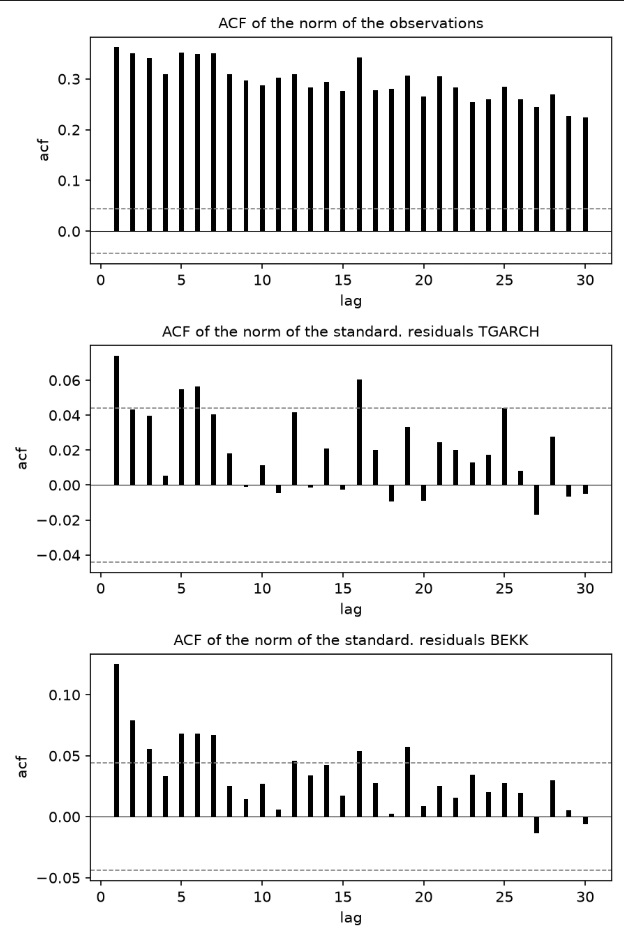

Вторая часть графиков

In [165]:

matplotlib.use("Agg")
import matplotlib.pyplot as plt

BREAK_DATE = "1997-05-30"


def make_figure2(U, theta_ccc, dates=None, out_path="figure2_std_resid_condstd.png"):
    H_diag, R, nu = ccc_recursion(theta_ccc, U)
    T = U.shape[0]

    if dates is None:
        x = np.arange(T)
        break_x = None
    else:
        x = pd.to_datetime(dates)
        break_x = pd.Timestamp(BREAK_DATE)

    fig, axes = plt.subplots(3, 2, figsize=(11, 9))

    for i, name in enumerate(ASSET_NAMES):
        cond_std = np.sqrt(H_diag[:, i])
        std_resid = U[:, i] / cond_std

        ax_resid = axes[i, 0]
        ax_resid.plot(x, std_resid, color="black", linewidth=0.5)
        ax_resid.set_title(f"{name} Standardized residuals", fontsize=10)
        ax_resid.axhline(0, color="gray", linewidth=0.5)
        if break_x is not None:
            ax_resid.axvline(break_x, color="red", linestyle="--", linewidth=0.7)

        ax_std = axes[i, 1]
        ax_std.plot(x, cond_std, color="black", linewidth=0.7)
        ax_std.set_title(f"{name} Conditional standard deviations", fontsize=10)
        if break_x is not None:
            ax_std.axvline(break_x, color="red", linestyle="--", linewidth=0.7)
            ax_std.annotate("8/97", xy=(break_x, ax_std.get_ylim()[1] * 0.9),
                             fontsize=8, color="red")

    plt.tight_layout()
    plt.savefig(out_path, dpi=150)

    return H_diag



sub = full_dataset_EX[["Date", "EX_US", "EX_UK", "EX_BD"]].dropna()
U = sub[["EX_US", "EX_UK", "EX_BD"]].values
dates = sub["Date"].values

make_figure2(U, theta_ccc=theta_hat_ccc, dates=dates)

array([[0.79993234, 0.81453173, 1.44974613],
       [0.78639615, 0.7860494 , 1.34479874],
       [0.74227021, 0.78133312, 1.25509027],
       ...,
       [4.75897706, 2.47439582, 2.48571   ],
       [4.53011999, 2.37907232, 2.2864627 ],
       [4.31655093, 2.30650074, 2.10795996]], shape=(1978, 3))

Fig 3 

In [166]:
matplotlib.use("Agg")
import matplotlib.pyplot as plt


PAIR_LABELS = {
    "USUK": "United States-United Kingdom",
    "USBD": "United States-Germany",
    "UKBD": "United Kingdom-Germany",
}


def make_figure3_exuberance(U, theta_ccc, dates=None,
                             out_path="figure3_covariances_exuberance.png"):
    cov_dict, ex_sq = compute_covariances(theta_ccc, U)
    T = U.shape[0]

    if dates is None:
        x = np.arange(T)
    else:
        x = pd.to_datetime(dates)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for ax, key in zip(axes, ["USUK", "USBD", "UKBD"]):
        ax.plot(x, cov_dict[key], color="black", linewidth=0.6)
        ax.set_title(PAIR_LABELS[key], fontsize=10)
        ax.axhline(0, color="gray", linewidth=0.5)

    fig.suptitle("Stock Market Exuberances -- conditional covariances", fontsize=12)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    return cov_dict


sub = full_dataset_EX[["Date", "EX_US", "EX_UK", "EX_BD"]].dropna()
U = sub[["EX_US", "EX_UK", "EX_BD"]].values
dates = sub["Date"].values

make_figure3_exuberance(U, theta_ccc=theta_hat_ccc, dates=dates)

{'USUK': array([0.24691971, 0.24050313, 0.23295619, ..., 1.04970319, 1.0042314 ,
        0.96520676], shape=(1978,)),
 'USBD': array([0.26452961, 0.25261028, 0.23709379, ..., 0.84485799, 0.79056683,
        0.74097114], shape=(1978,)),
 'UKBD': array([0.54642969, 0.51699682, 0.49795478, ..., 1.24707945, 1.17278982,
        1.10877209], shape=(1978,))}